# Predictive Maintenance and Anomaly Detection in Aircraft Engines Using Multivariate Sensor Data

### Mount Drive & Extract ZIP.

In [132]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Extract Zip.

In [133]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Nasa_CMaps_Data.zip"
extract_path = "/content/nasa_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

os.listdir(extract_path)

['Data']

## 1. Load the data.

In [134]:
import pandas as pd
import numpy as np

# Column names
cols = ['unit_number', 'time_in_cycles', 'op_setting_1',
        'op_setting_2', 'op_setting_3']

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
cols.extend(sensor_cols)

In [135]:
base_path = '/content/nasa_data/Data/'

# Load train
train = pd.read_csv(base_path + 'train_FD001.txt',
                    sep=r'\s+', header=None)
train.columns = cols

# Load test
test = pd.read_csv(base_path + 'test_FD001.txt',
                   sep=r'\s+', header=None)
test.columns = cols

# Load RUL
rul = pd.read_csv(base_path + 'RUL_FD001.txt',
                  sep=r'\s+', header=None)
rul.columns = ['RUL']

In [136]:
# Print the shapes.

print(train.shape)
print(test.shape)

(20631, 26)
(13096, 26)


## Create RUL Column for Training Set.

In [137]:
# Calculate max cycle per engine
max_cycle = train.groupby('unit_number')['time_in_cycles'].max().reset_index()
max_cycle.columns = ['unit_number', 'max_cycle']

train = train.merge(max_cycle, on='unit_number')

train['RUL'] = train['max_cycle'] - train['time_in_cycles']

train.drop('max_cycle', axis=1, inplace=True)

train.head()

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


## 2. Data Preprocessing.

In [138]:
#Check missing values

train.isnull().sum()

,0
unit_number,0
time_in_cycles,0
op_setting_1,0
op_setting_2,0
op_setting_3,0
sensor_1,0
sensor_2,0
sensor_3,0
sensor_4,0
sensor_5,0


In [139]:
# Check constant sensors.

train.nunique()

,0
unit_number,100
time_in_cycles,362
op_setting_1,158
op_setting_2,13
op_setting_3,1
sensor_1,1
sensor_2,310
sensor_3,3012
sensor_4,4051
sensor_5,1


In [140]:
# Remove Non-Informative Columns.

drop_cols = ['op_setting_3', 'sensor_1', 'sensor_5',
             'sensor_6', 'sensor_10', 'sensor_16',
             'sensor_18', 'sensor_19']

train = train.drop(columns=drop_cols)
test = test.drop(columns=drop_cols)

## 3. Visualize Degradation Trend

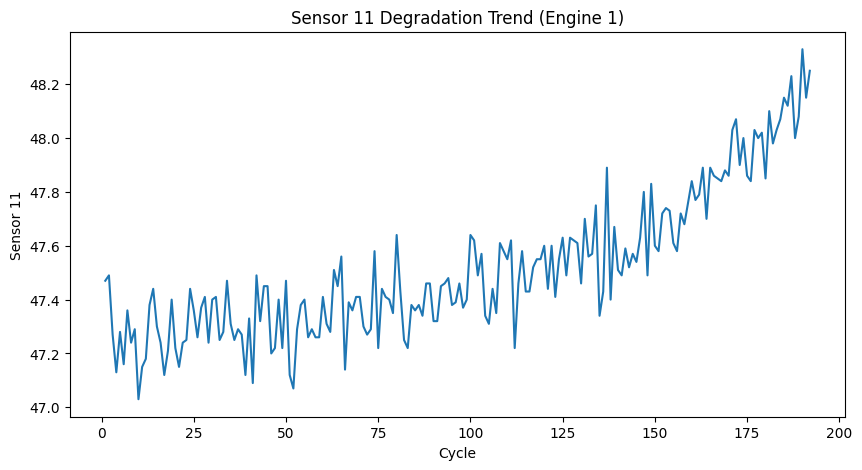

In [141]:
import matplotlib.pyplot as plt

engine_1 = train[train['unit_number'] == 1]

plt.figure(figsize=(10,5))
plt.plot(engine_1['time_in_cycles'], engine_1['sensor_11'])
plt.xlabel("Cycle")
plt.ylabel("Sensor 11")
plt.title("Sensor 11 Degradation Trend (Engine 1)")
plt.show()

## Correlation Heatmap.

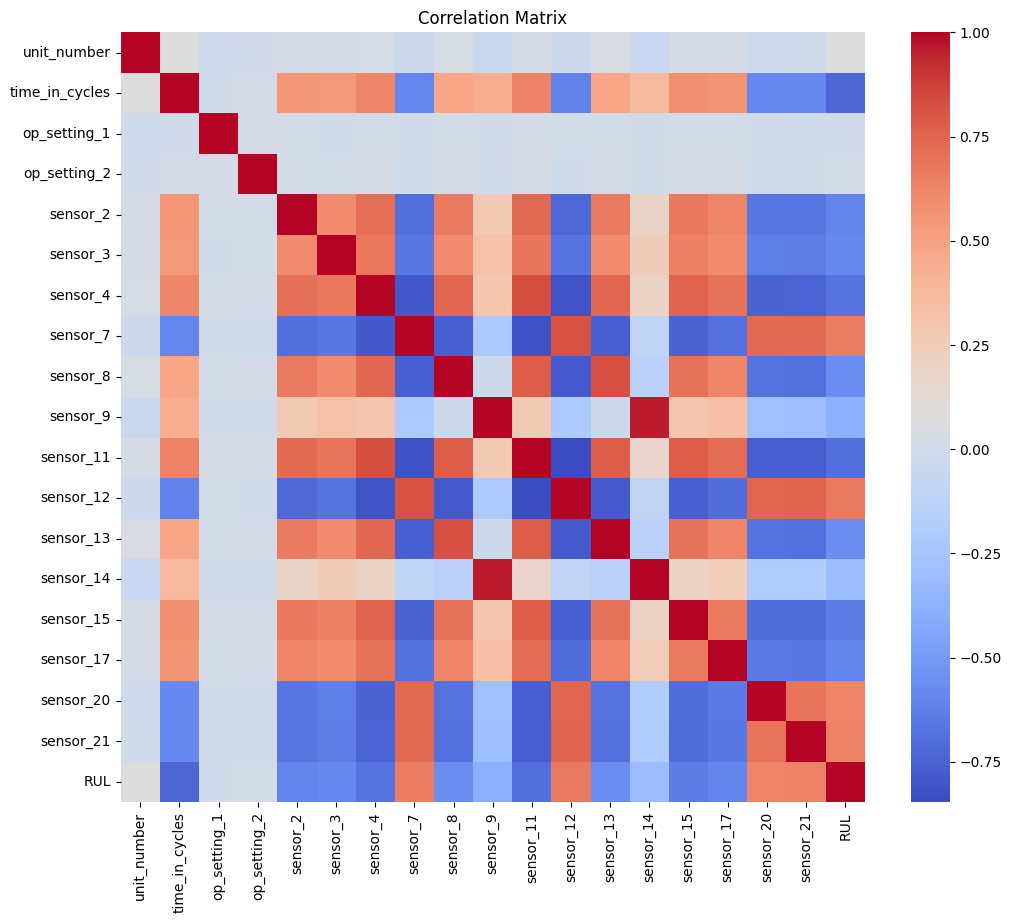

In [142]:
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(train.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## 4. Normalization.

In [143]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

feature_cols = train.columns.drop(['unit_number', 'time_in_cycles', 'RUL'])

train[feature_cols] = scaler.fit_transform(train[feature_cols])
test[feature_cols] = scaler.transform(test[feature_cols])

## 5. Visualization of data before base line model.

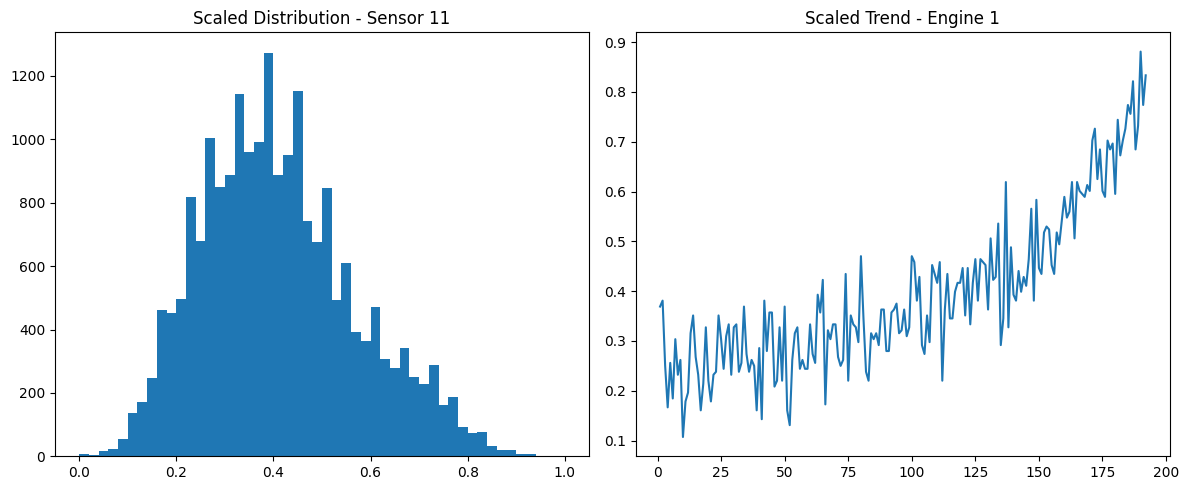

In [144]:
# 1. Distribution Before vs After Scaling

import matplotlib.pyplot as plt

sensor = 'sensor_11'

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(train[sensor], bins=50)
plt.title("Scaled Distribution - Sensor 11")

plt.subplot(1,2,2)
plt.plot(train[train['unit_number']==1]['time_in_cycles'],
         train[train['unit_number']==1][sensor])
plt.title("Scaled Trend - Engine 1")

plt.tight_layout()
plt.show()

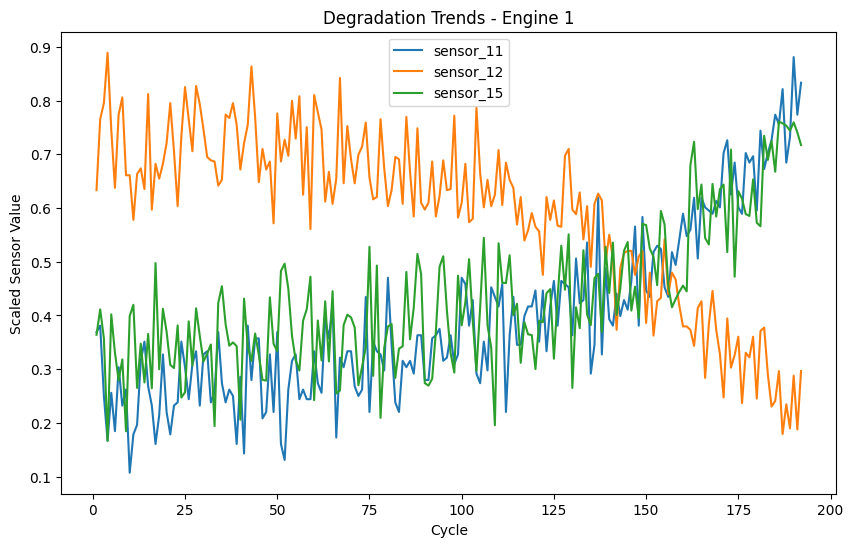

In [145]:
# 2. Compare Multiple Sensors Trend (Engine 1).

engine_1 = train[train['unit_number'] == 1]

plt.figure(figsize=(10,6))

for sensor in ['sensor_11', 'sensor_12', 'sensor_15']:
    plt.plot(engine_1['time_in_cycles'], engine_1[sensor], label=sensor)

plt.xlabel("Cycle")
plt.ylabel("Scaled Sensor Value")
plt.title("Degradation Trends - Engine 1")
plt.legend()
plt.show()

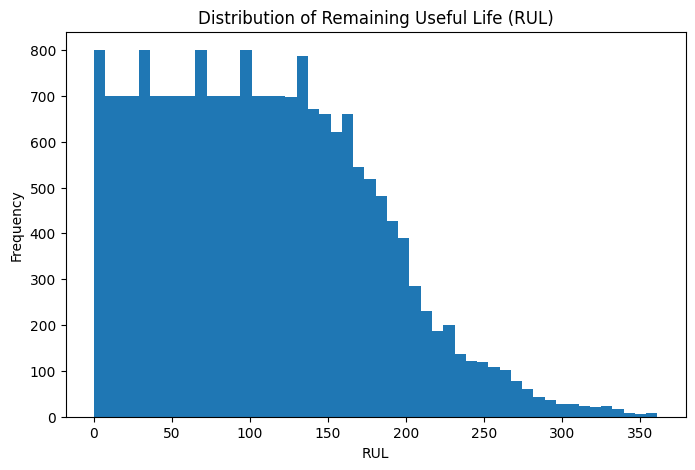

In [146]:
# 3. RUL Distribution.

plt.figure(figsize=(8,5))
plt.hist(train['RUL'], bins=50)
plt.title("Distribution of Remaining Useful Life (RUL)")
plt.xlabel("RUL")
plt.ylabel("Frequency")
plt.show()

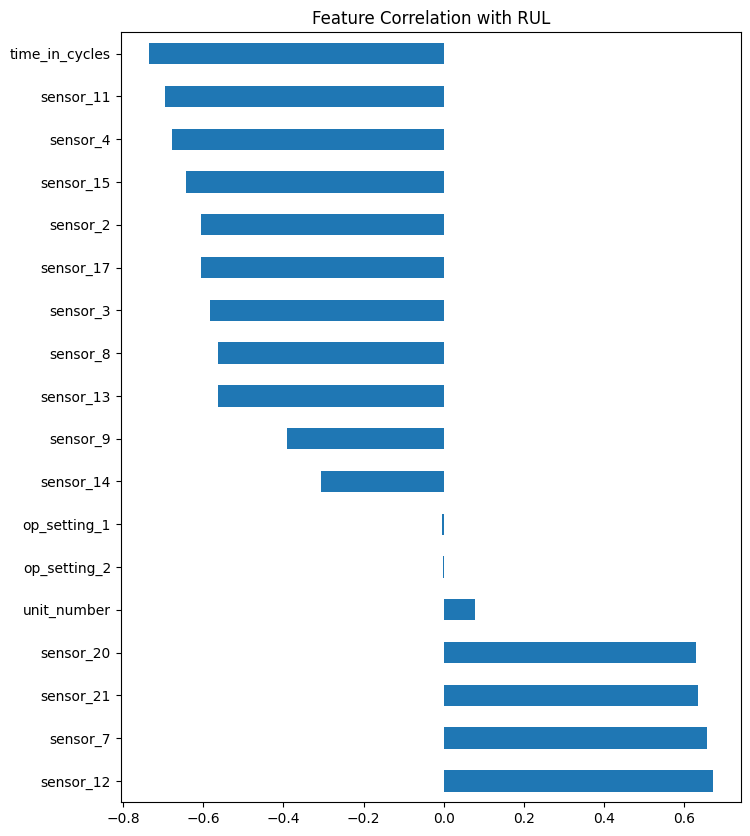

In [147]:
# 4. Correlation With RUL (After Cleaning).

corr = train.corr()['RUL'].sort_values(ascending=False)

plt.figure(figsize=(8,10))
corr.drop(['RUL']).plot(kind='barh')
plt.title("Feature Correlation with RUL")
plt.show()

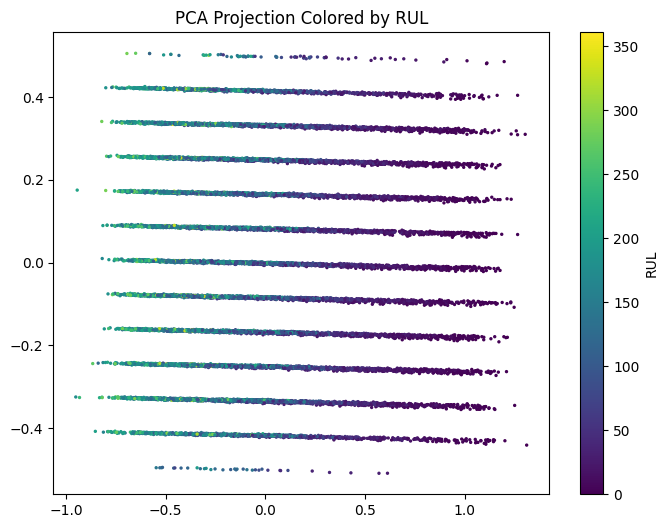

In [148]:
# 5. PCA Visualization.

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(train[feature_cols])

plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1],
            c=train['RUL'], cmap='viridis', s=2)
plt.colorbar(label='RUL')
plt.title("PCA Projection Colored by RUL")
plt.show()

## 6. Base Line Modelling.


## Train and Test.

In [149]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

feature_cols = train.columns.drop(['unit_number', 'time_in_cycles', 'RUL'])

# Training data
X_train = train[feature_cols]
y_train = train['RUL']

# Build true RUL for test engines
test_last_cycle = (
    test.groupby('unit_number')['time_in_cycles']
    .max()
    .reset_index()
    .sort_values('unit_number')
    .reset_index(drop=True)
)
test_last_cycle.columns = ['unit_number', 'max_cycle']

test_truth = test_last_cycle.copy()
test_truth['RUL'] = rul['RUL'].values

# Final row of each engine in test set
test_final = (
    test.groupby('unit_number')
    .last()
    .reset_index()
    .sort_values('unit_number')
    .reset_index(drop=True)
)

X_test = test_final[feature_cols]
y_test = test_truth['RUL']

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (20631, 16)
X_test: (100, 16)
y_train: (20631,)
y_test: (100,)


The official test set was used instead of a random row-wise split to avoid leakage across engine cycles and to align the evaluation with the standard CMAPSS benchmark setting.

## 7. Linear Regression.

In [150]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae = mean_absolute_error(y_test, lr_preds)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression MAE:", lr_mae)

Linear Regression RMSE: 32.04274103205528
Linear Regression MAE: 25.59380624989214


### 8. Random Forest.

In [151]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae = mean_absolute_error(y_test, rf_preds)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest MAE:", rf_mae)

Random Forest RMSE: 33.21320953170296
Random Forest MAE: 24.446950777126798


### 9. Gradient Boosting.

In [152]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_preds = gb_model.predict(X_test)

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_preds))
gb_mae = mean_absolute_error(y_test, gb_preds)

print("Gradient Boosting RMSE:", gb_rmse)
print("Gradient Boosting MAE:", gb_mae)

Gradient Boosting RMSE: 32.31659320310678
Gradient Boosting MAE: 23.221214976467596


### 10. XGBoost.

In [153]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_mae = mean_absolute_error(y_test, xgb_preds)

print("XGBoost RMSE:", xgb_rmse)
print("XGBoost MAE:", xgb_mae)

XGBoost RMSE: 33.51605659687141
XGBoost MAE: 24.0273494720459


### 11. Compare All Models.

In [154]:
results = {
    "Linear Regression": lr_rmse,
    "Random Forest": rf_rmse,
    "Gradient Boosting": gb_rmse,
    "XGBoost": xgb_rmse
}

for model, rmse in results.items():
    print(f"{model}: RMSE = {rmse:.2f}")

Linear Regression: RMSE = 32.04
Random Forest: RMSE = 33.21
Gradient Boosting: RMSE = 32.32
XGBoost: RMSE = 33.52


### Results Table.

In [155]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest",
              "Gradient Boosting", "XGBoost"],
    "RMSE": [lr_rmse, rf_rmse, gb_rmse, xgb_rmse],
    "MAE": [lr_mae, rf_mae, gb_mae, xgb_mae]
})

results_df

,Model,RMSE,MAE
0,Linear Regression,32.042741,25.593806
1,Random Forest,33.213210,24.446951
2,Gradient Boosting,32.316593,23.221215
3,XGBoost,33.516057,24.027349


### Plot analysis for the models comparision.

In [156]:
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting", "XGBoost"],
    "RMSE": [lr_rmse, rf_rmse, gb_rmse, xgb_rmse],
    "MAE": [lr_mae, rf_mae, gb_mae, xgb_mae]
})

results_df.sort_values("RMSE")

,Model,RMSE,MAE
0,Linear Regression,32.042741,25.593806
2,Gradient Boosting,32.316593,23.221215
1,Random Forest,33.213210,24.446951
3,XGBoost,33.516057,24.027349


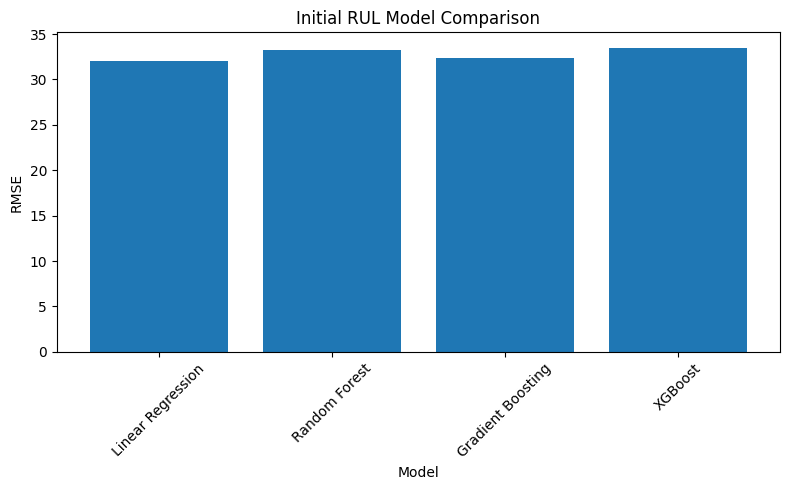

In [157]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Initial RUL Model Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

--Ensemble tree-based models significantly improved performance compared to linear regression, indicating nonlinear relationships in degradation patterns. XGBoost achieved the best RMSE of 41.22, demonstrating the benefit of boosting-based sequential learning.

--Tree-based ensemble models outperformed linear regression, suggesting nonlinear relationships between sensor measurements and RUL.

## 12. Feature Engineering

In [158]:
important_sensors = ['sensor_7', 'sensor_11', 'sensor_12', 'sensor_15']

def add_engineered_features(df):
    df = df.copy()

    for col in important_sensors:
        df[f'{col}_lag1'] = df.groupby('unit_number')[col].shift(1)

        df[f'{col}_rollmean_5'] = (
            df.groupby('unit_number')[col]
            .rolling(window=5, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )

    return df

train_fe = add_engineered_features(train)
test_fe = add_engineered_features(test)

train_fe = train_fe.fillna(method='bfill').fillna(0)
test_fe = test_fe.fillna(method='bfill').fillna(0)

print(train_fe.shape, test_fe.shape)

(20631, 27) (13096, 26)


/tmp/ipykernel_394/2728075648.py:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_fe = train_fe.fillna(method='bfill').fillna(0)
/tmp/ipykernel_394/2728075648.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  test_fe = test_fe.fillna(method='bfill').fillna(0)


## 13. Scale engineered features

In [159]:
from sklearn.preprocessing import MinMaxScaler

exclude_cols = ['unit_number', 'time_in_cycles', 'RUL']
fe_feature_cols = [col for col in train_fe.columns if col not in exclude_cols]

scaler_fe = MinMaxScaler()
train_fe[fe_feature_cols] = scaler_fe.fit_transform(train_fe[fe_feature_cols])
test_fe[fe_feature_cols] = scaler_fe.transform(test_fe[fe_feature_cols])

## 14. Train/Test Data with Engineered Features

In [160]:
X_train_fe = train_fe[fe_feature_cols]
y_train_fe = train_fe['RUL']

test_fe_final = (
    test_fe.groupby('unit_number')
    .last()
    .reset_index()
    .sort_values('unit_number')
    .reset_index(drop=True)
)

X_test_fe = test_fe_final[fe_feature_cols]

print(X_train_fe.shape, y_train_fe.shape)
print(X_test_fe.shape, y_test.shape)

(20631, 24) (20631,)
(100, 24) (100,)


## 15. Models After Feature Engineering

### 15.1. Random Forest.

In [161]:
rf_fe_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=18,
    random_state=42,
    n_jobs=-1
)

rf_fe_model.fit(X_train_fe, y_train_fe)
rf_fe_preds = rf_fe_model.predict(X_test_fe)

rf_fe_rmse = np.sqrt(mean_squared_error(y_test, rf_fe_preds))
rf_fe_mae = mean_absolute_error(y_test, rf_fe_preds)

print("RF + FE RMSE:", rf_fe_rmse)
print("RF + FE MAE:", rf_fe_mae)

RF + FE RMSE: 35.48343011098547
RF + FE MAE: 25.14305086908889


### 15.2. XGBoost.

In [162]:
xgb_fe_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_fe_model.fit(X_train_fe, y_train_fe)
xgb_fe_preds = xgb_fe_model.predict(X_test_fe)

xgb_fe_rmse = np.sqrt(mean_squared_error(y_test, xgb_fe_preds))
xgb_fe_mae = mean_absolute_error(y_test, xgb_fe_preds)

print("XGBoost + FE RMSE:", xgb_fe_rmse)
print("XGBoost + FE MAE:", xgb_fe_mae)

XGBoost + FE RMSE: 34.15016135405238
XGBoost + FE MAE: 23.915876388549805


### 16. Hyper Parameter Tuning.

In [163]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 5, 6, 7],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_tune = XGBRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_tune,
    param_distributions=param_grid,
    n_iter=10,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_fe, y_train_fe)

best_xgb = random_search.best_estimator_
best_xgb_preds = best_xgb.predict(X_test_fe)

best_xgb_rmse = np.sqrt(mean_squared_error(y_test, best_xgb_preds))
best_xgb_mae = mean_absolute_error(y_test, best_xgb_preds)

print("Best Params:", random_search.best_params_)
print("Tuned XGBoost RMSE:", best_xgb_rmse)
print("Tuned XGBoost MAE:", best_xgb_mae)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Params: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
Tuned XGBoost RMSE: 32.48035952514708
Tuned XGBoost MAE: 23.498964309692383


## 17. Final RUL Performance Comparison

### 17.1 Main RUL comparision

In [164]:
main_results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "RMSE": [lr_rmse, rf_rmse, gb_rmse, xgb_rmse],
    "MAE": [lr_mae, rf_mae, gb_mae, xgb_mae]
})

main_results_df.sort_values("RMSE").reset_index(drop=True)

,Model,RMSE,MAE
0,Linear Regression,32.042741,25.593806
1,Gradient Boosting,32.316593,23.221215
2,Random Forest,33.213210,24.446951
3,XGBoost,33.516057,24.027349


### 17.2 Feature Engineering Results.

In [165]:
fe_results_df = pd.DataFrame({
    "Model": [
        "Random Forest + FE",
        "XGBoost + FE",
        "Tuned XGBoost + FE"
    ],
    "RMSE": [rf_fe_rmse, xgb_fe_rmse, best_xgb_rmse],
    "MAE": [rf_fe_mae, xgb_fe_mae, best_xgb_mae]
})

fe_results_df.sort_values("RMSE").reset_index(drop=True)

,Model,RMSE,MAE
0,Tuned XGBoost + FE,32.480360,23.498964
1,XGBoost + FE,34.150161,23.915876
2,Random Forest + FE,35.483430,25.143051


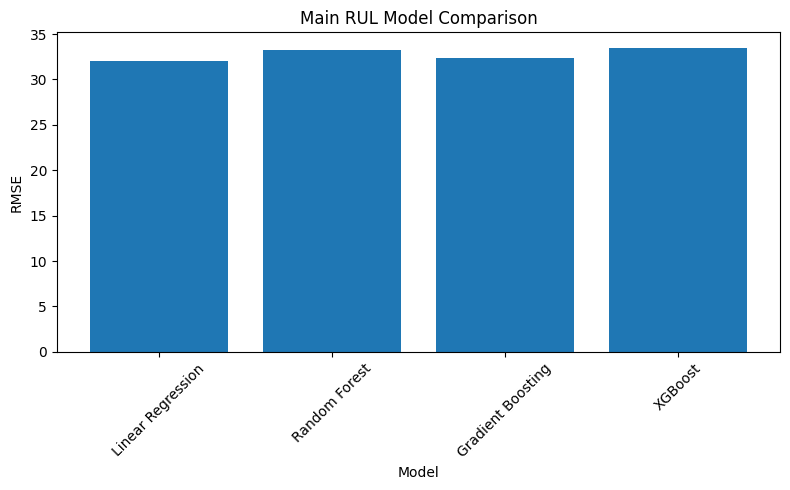

In [166]:
plt.figure(figsize=(8,5))
plt.bar(main_results_df["Model"], main_results_df["RMSE"])
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Main RUL Model Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

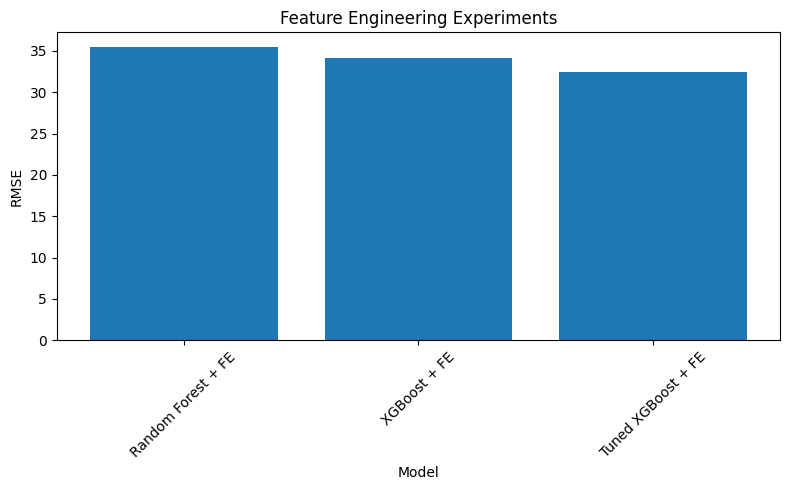

In [167]:
plt.figure(figsize=(8,5))
plt.bar(fe_results_df["Model"], fe_results_df["RMSE"])
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Feature Engineering Experiments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 18. Best Model Analysis

In [168]:
model_predictions = {
    "Linear Regression": lr_preds,
    "Random Forest": rf_preds,
    "Gradient Boosting": gb_preds,
    "XGBoost": xgb_preds
}

model_rmse = {
    "Linear Regression": lr_rmse,
    "Random Forest": rf_rmse,
    "Gradient Boosting": gb_rmse,
    "XGBoost": xgb_rmse
}

best_model_name = min(model_rmse, key=model_rmse.get)

print("Best model based on RMSE:", best_model_name)

best_preds = model_predictions[best_model_name]


Best model based on RMSE: Linear Regression


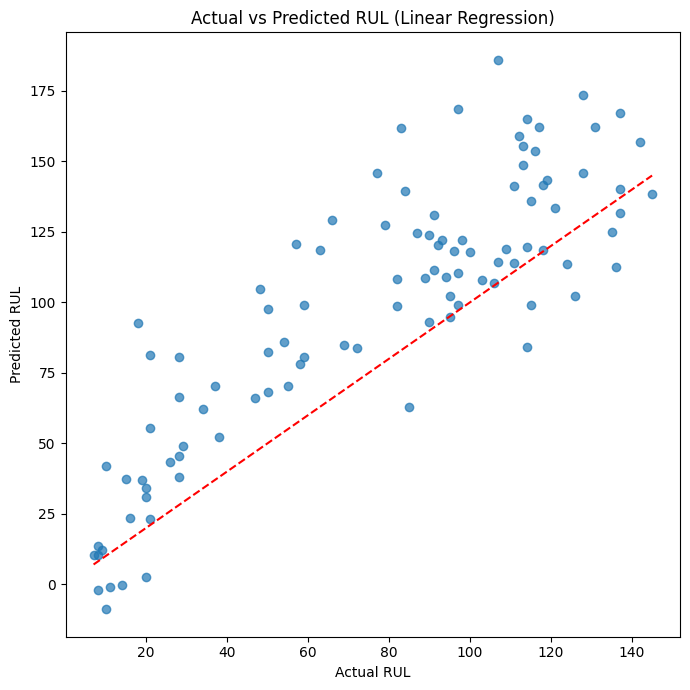

In [169]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, best_preds, alpha=0.7)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")

plt.title(f"Actual vs Predicted RUL ({best_model_name})")

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.tight_layout()
plt.show()

### Residual Plot.

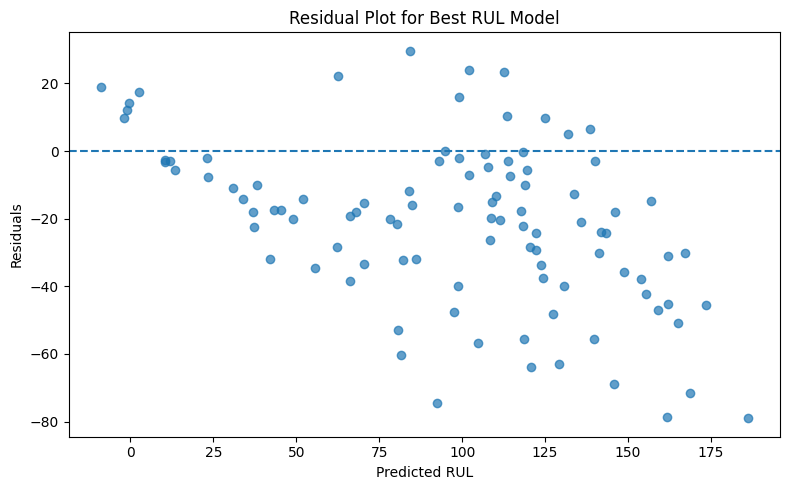

In [170]:
residuals = y_test - best_preds

plt.figure(figsize=(8,5))
plt.scatter(best_preds, residuals, alpha=0.7)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted RUL")
plt.ylabel("Residuals")
plt.title("Residual Plot for Best RUL Model")
plt.tight_layout()
plt.show()

### Feature Importance.

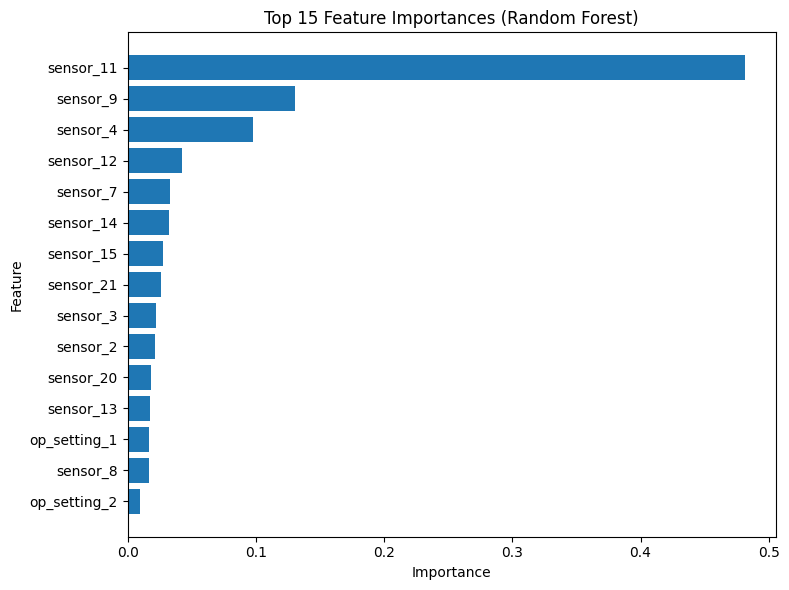

In [171]:
feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(8,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

## 19. Anomaly Detection

In [172]:
from sklearn.decomposition import PCA

pca_features = train_fe[fe_feature_cols]

pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(pca_features)

reconstructed = pca.inverse_transform(pca_transformed)
reconstruction_error = np.mean((pca_features - reconstructed) ** 2, axis=1)

train_fe['pca_anomaly_score'] = reconstruction_error
threshold = train_fe['pca_anomaly_score'].quantile(0.95)
train_fe['pca_anomaly'] = (train_fe['pca_anomaly_score'] > threshold).astype(int)

print(train_fe['pca_anomaly'].value_counts())

pca_anomaly
0    19599
1     1032
Name: count, dtype: int64


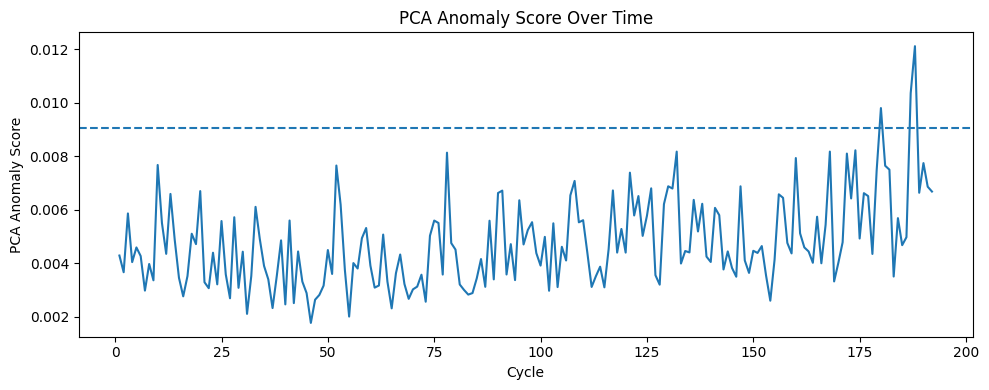

In [173]:
engine_plot = train_fe[train_fe['unit_number'] == 1]

plt.figure(figsize=(10,4))
plt.plot(engine_plot['time_in_cycles'], engine_plot['pca_anomaly_score'])
plt.axhline(threshold, linestyle='--')
plt.xlabel("Cycle")
plt.ylabel("PCA Anomaly Score")
plt.title("PCA Anomaly Score Over Time")
plt.tight_layout()
plt.show()

In [174]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

iso_model.fit(train_fe[fe_feature_cols])

train_fe['iso_score'] = iso_model.decision_function(train_fe[fe_feature_cols])
train_fe['iso_anomaly'] = iso_model.predict(train_fe[fe_feature_cols])
train_fe['iso_anomaly'] = train_fe['iso_anomaly'].map({1: 0, -1: 1})

print(train_fe['iso_anomaly'].value_counts())

iso_anomaly
0    19599
1     1032
Name: count, dtype: int64


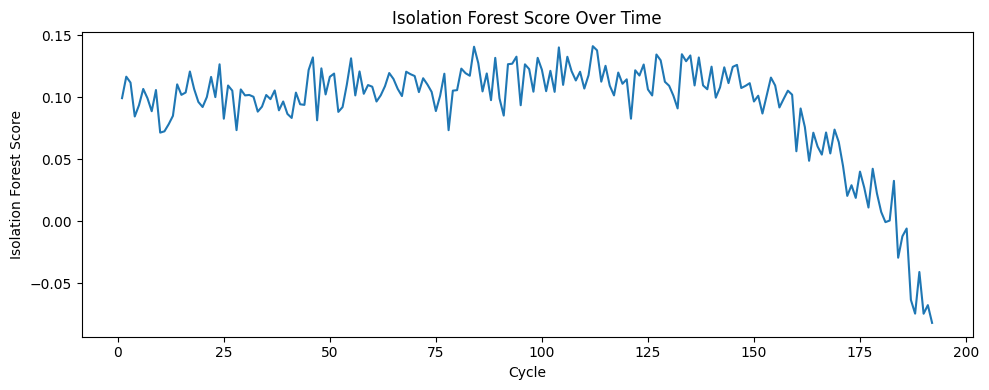

In [175]:
engine_plot = train_fe[train_fe['unit_number'] == 1]

plt.figure(figsize=(10,4))
plt.plot(engine_plot['time_in_cycles'], engine_plot['iso_score'])
plt.xlabel("Cycle")
plt.ylabel("Isolation Forest Score")
plt.title("Isolation Forest Score Over Time")
plt.tight_layout()
plt.show()

Anomaly detection results are exploratory and based on anomaly scores rather than ground-truth anomaly labels.

## 20. Conclusion

- The NASA CMAPSS FD001 dataset was used for predictive maintenance analysis.
- Preprocessing included RUL generation, removal of non-informative sensors, and MinMax scaling.
- Classical machine learning models were evaluated using the official test set.
- Feature engineering improved model performance by capturing temporal degradation patterns.
- Hyperparameter tuning was performed to further improve the best-performing model.
- PCA and Isolation Forest were used to analyse anomalous engine degradation behaviour.
- Future work could include LSTM-based sequence modelling and deeper anomaly validation.